In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ GPU е наличен и memory growth е включен.")
else:
    print("❌ TensorFlow не вижда GPU. Ще тренира на CPU.")

TensorFlow version: 2.10.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU е наличен и memory growth е включен.


In [3]:
DATASET_CSV = r"D:\Магистър\Общ проект\dataset_mri_pet_labels.csv"

dataset_df = pd.read_csv(DATASET_CSV)

print("Dataset shape:", dataset_df.shape)
display(dataset_df.head())

print("Разпределение по диагноза:")
print(dataset_df["diagnosis"].value_counts())

Dataset shape: (458, 5)


,subject_id,mri_path,pet_path,diagnosis,label
0,002_S_0295,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
1,002_S_0413,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
2,002_S_0685,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
3,002_S_1261,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
4,002_S_1280,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0


Разпределение по диагноза:
diagnosis
CN    311
AD    147
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    dataset_df,
    test_size=0.20,
    random_state=42,
    stratify=dataset_df["label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=42,
    stratify=train_val_df["label"]
)

print("Train:", len(train_df))
print(train_df["diagnosis"].value_counts())
print()

print("Validation:", len(val_df))
print(val_df["diagnosis"].value_counts())
print()

print("Test:", len(test_df))
print(test_df["diagnosis"].value_counts())

Train: 292
diagnosis
CN    199
AD     93
Name: count, dtype: int64

Validation: 74
diagnosis
CN    50
AD    24
Name: count, dtype: int64

Test: 92
diagnosis
CN    62
AD    30
Name: count, dtype: int64


In [5]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])  # CN = 0, AD = 1

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: class_weights_values[0],
    1: class_weights_values[1]
}

print("Class weights:", class_weights)

Class weights: {0: 0.7336683417085427, 1: 1.5698924731182795}


In [6]:
import tensorflow as tf
import numpy as np

BATCH_SIZE = 2
INPUT_SHAPE = (64, 64, 64, 2)

def downsample_volume(volume):
    """
    Намалява 128x128x128 до 64x64x64 чрез вземане на всяка втора стойност.
    """
    return volume[::2, ::2, ::2]

def load_sample(mri_path, pet_path, label):
    mri_path = mri_path.decode("utf-8")
    pet_path = pet_path.decode("utf-8")

    mri = np.load(mri_path).astype("float32")
    pet = np.load(pet_path).astype("float32")

    mri = downsample_volume(mri)
    pet = downsample_volume(pet)

    # MRI и PET като два канала
    x = np.stack([mri, pet], axis=-1)

    y = np.float32(label)

    return x, y

def tf_load_sample(mri_path, pet_path, label):
    x, y = tf.numpy_function(
        load_sample,
        [mri_path, pet_path, label],
        [tf.float32, tf.float32]
    )

    x.set_shape(INPUT_SHAPE)
    y.set_shape(())

    return x, y

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["mri_path"].values,
        df["pet_path"].values,
        df["label"].values.astype("float32")
    ))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(tf_load_sample, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("✅ TensorFlow datasets са готови.")

for x_batch, y_batch in train_ds.take(1):
    print("X batch shape:", x_batch.shape)
    print("Y batch shape:", y_batch.shape)

✅ TensorFlow datasets са готови.
X batch shape: (2, 64, 64, 64, 2)
Y batch shape: (2,)


In [7]:
from tensorflow.keras import layers, models, regularizers

def residual_block_3d(x, filters, stride=1, name=None):
    shortcut = x

    x = layers.Conv3D(
        filters,
        kernel_size=3,
        strides=stride,
        padding="same",
        use_bias=False,
        name=None if name is None else name + "_conv1"
    )(x)
    x = layers.BatchNormalization(name=None if name is None else name + "_bn1")(x)
    x = layers.Activation("relu", name=None if name is None else name + "_relu1")(x)

    x = layers.Conv3D(
        filters,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False,
        name=None if name is None else name + "_conv2"
    )(x)
    x = layers.BatchNormalization(name=None if name is None else name + "_bn2")(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv3D(
            filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            use_bias=False,
            name=None if name is None else name + "_shortcut_conv"
        )(shortcut)
        shortcut = layers.BatchNormalization(
            name=None if name is None else name + "_shortcut_bn"
        )(shortcut)

    x = layers.Add(name=None if name is None else name + "_add")([x, shortcut])
    x = layers.Activation("relu", name=None if name is None else name + "_relu_out")(x)

    return x


def build_small_3d_resnet_classifier(input_shape=(64, 64, 64, 2)):
    inputs = layers.Input(shape=input_shape, name="mri_pet_input")

    # Stem
    x = layers.Conv3D(
        16,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False,
        name="stem_conv"
    )(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.Activation("relu", name="stem_relu")(x)
    x = layers.MaxPooling3D(pool_size=2, name="stem_pool")(x)  # 32x32x32

    # Малък ResNet backbone
    x = residual_block_3d(x, 16, stride=1, name="res_block_1")  # 32
    x = residual_block_3d(x, 32, stride=2, name="res_block_2")  # 16
    x = residual_block_3d(x, 64, stride=2, name="res_block_3")  # 8

    x = layers.GlobalAveragePooling3D(name="global_avg_pool")(x)

    x = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_32"
    )(x)
    x = layers.Dropout(0.5, name="dropout")(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="classification_output"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Model1_Small_3D_ResNet_AD_CN"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

model1 = build_small_3d_resnet_classifier()
model1.summary()

Model: "Model1_Small_3D_ResNet_AD_CN"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 mri_pet_input (InputLayer)     [(None, 64, 64, 64,  0           []                               
                                 2)]                                                              
                                                                                                  
 stem_conv (Conv3D)             (None, 64, 64, 64,   864         ['mri_pet_input[0][0]']          
                                16)                                                               
                                                                                                  
 stem_bn (BatchNormalization)   (None, 64, 64, 64,   64          ['stem_conv[0][0]']              
                                16)                                    

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "model1_small_3d_resnet.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [9]:
history1 = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/30
146/146 [==============================] - ETA: 0s - loss: 0.7225 - accuracy: 0.5240 - precision: 0.3506 - sensitivity: 0.5806 - auc: 0.5194
Epoch 1: val_loss improved from inf to 0.76733, saving model to model1_small_3d_resnet.keras
146/146 [==============================] - 19s 96ms/step - loss: 0.7225 - accuracy: 0.5240 - precision: 0.3506 - sensitivity: 0.5806 - auc: 0.5194 - val_loss: 0.7673 - val_accuracy: 0.3243 - val_precision: 0.3243 - val_sensitivity: 1.0000 - val_auc: 0.6242 - lr: 1.0000e-04
Epoch 2/30
146/146 [==============================] - ETA: 0s - loss: 0.6813 - accuracy: 0.5582 - precision: 0.3875 - sensitivity: 0.6667 - auc: 0.6125
Epoch 2: val_loss did not improve from 0.76733
146/146 [==============================] - 13s 92ms/step - loss: 0.6813 - accuracy: 0.5582 - precision: 0.3875 - sensitivity: 0.6667 - auc: 0.6125 - val_loss: 0.7843 - val_accuracy: 0.3243 - val_precision: 0.3243 - val_sensitivity: 1.0000 - val_auc: 0.7625 - lr: 1.0000e-04
Epoch 3/

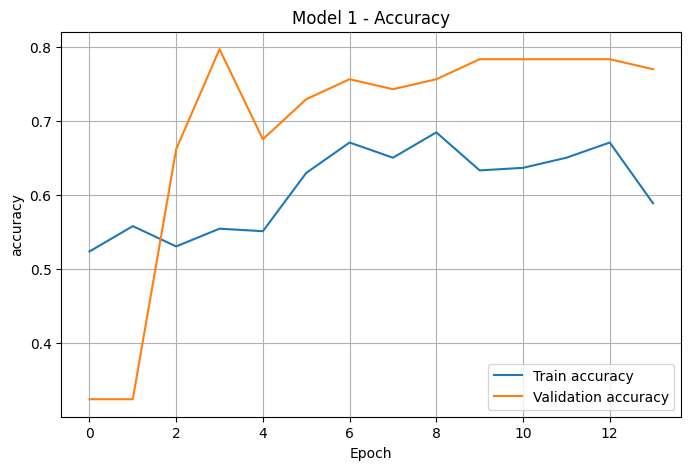

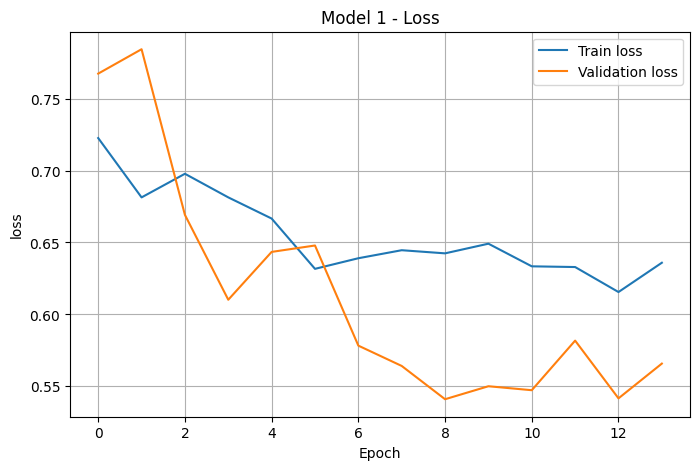

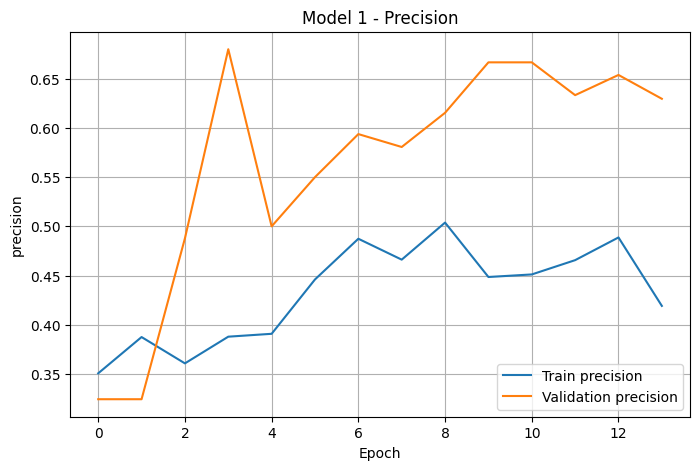

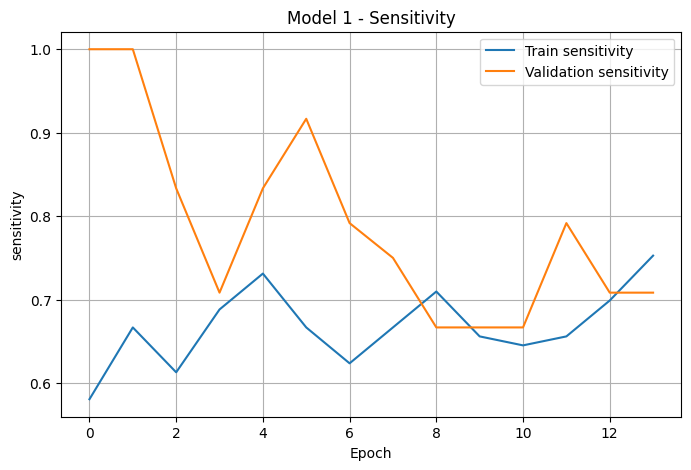

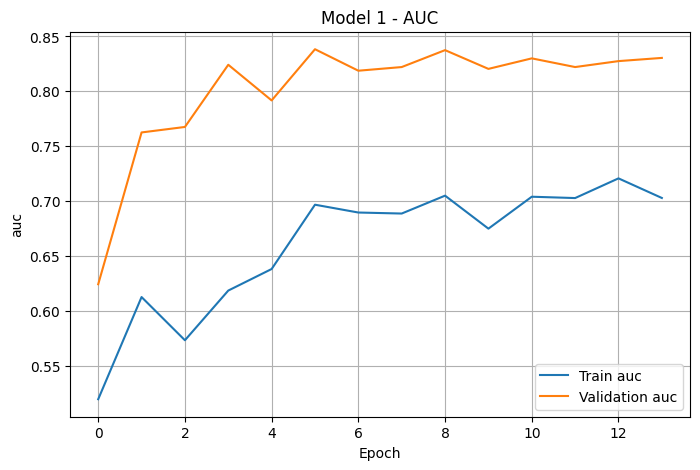

In [10]:
import matplotlib.pyplot as plt

def plot_metric(history, metric, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[metric], label=f"Train {metric}")
    plt.plot(history.history[f"val_{metric}"], label=f"Validation {metric}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_metric(history1, "accuracy", "Model 1 - Accuracy", "model1_accuracy.png")
plot_metric(history1, "loss", "Model 1 - Loss", "model1_loss.png")
plot_metric(history1, "precision", "Model 1 - Precision", "model1_precision.png")
plot_metric(history1, "sensitivity", "Model 1 - Sensitivity", "model1_sensitivity.png")
plot_metric(history1, "auc", "Model 1 - AUC", "model1_auc.png")

In [11]:
test_results = model1.evaluate(test_ds, verbose=1)

print("Test results:")
for name, value in zip(model1.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

46/46 [==============================] - 2s 30ms/step - loss: 0.6142 - accuracy: 0.6848 - precision: 0.5217 - sensitivity: 0.4000 - auc: 0.6642
Test results:
loss: 0.6142
accuracy: 0.6848
precision: 0.5217
sensitivity: 0.4000
auc: 0.6642


In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_prob = []

for x_batch, y_batch in test_ds:
    preds = model1.predict(x_batch, verbose=0)
    y_prob.extend(preds.ravel())
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print()
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")
print()

print(classification_report(
    y_true,
    y_pred,
    target_names=["CN", "AD"]
))

Confusion Matrix:
[[51 11]
 [18 12]]

TN: 51
FP: 11
FN: 18
TP: 12

              precision    recall  f1-score   support

          CN       0.74      0.82      0.78        62
          AD       0.52      0.40      0.45        30

    accuracy                           0.68        92
   macro avg       0.63      0.61      0.62        92
weighted avg       0.67      0.68      0.67        92



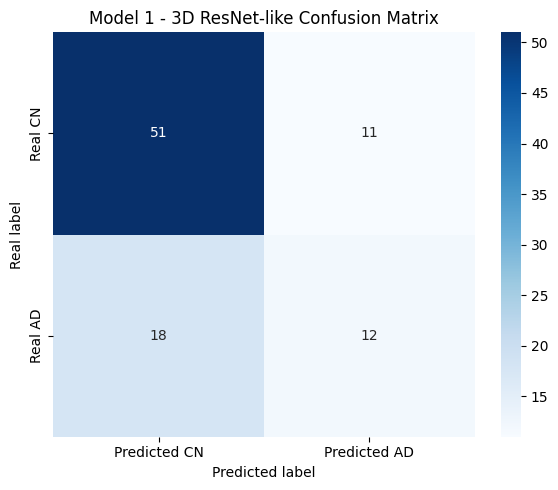

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted CN", "Predicted AD"],
    yticklabels=["Real CN", "Real AD"]
)

plt.title("Model 1 - 3D ResNet-like Confusion Matrix")
plt.ylabel("Real label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("model1_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
test_results = model1.evaluate(test_ds, verbose=1)

print("Test results:")
for name, value in zip(model1.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

46/46 [==============================] - 2s 29ms/step - loss: 0.6142 - accuracy: 0.6848 - precision: 0.5217 - sensitivity: 0.4000 - auc: 0.6642
Test results:
loss: 0.6142
accuracy: 0.6848
precision: 0.5217
sensitivity: 0.4000
auc: 0.6642


In [17]:
model1_results = {
    "model": "Model 2 - 3D ResNet-like MRI/PET Classifier",
    "test_loss": test_results[0],
    "test_accuracy": test_results[1],
    "test_precision": test_results[2],
    "test_sensitivity": test_results[3],
    "test_auc": test_results[4],
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}

model1_results_df = pd.DataFrame([model1_results])

display(model1_results_df)

model1_results_df.to_csv("model2_results.csv", index=False)

print("💾 Запазено: model2_results.csv")

,model,test_loss,test_accuracy,test_precision,test_sensitivity,test_auc,TN,FP,FN,TP
0,Model 2 - 3D ResNet-like MRI/PET Classifier,0.61418,0.684783,0.521739,0.4,0.664247,51,11,18,12


💾 Запазено: model2_results.csv
